# Question 2

## Problem Statement

Consider a CSTR with a second order reaction. At constant volume and constant density the model equation is as follows

$$
\frac{dC}{dt} = \frac{F}{V} C_i - \frac{F}{V} C - k_2 C^2
$$

Use the following parameters: $\frac{V}{F} = 5\ \text{min}, k_2 = 0.02\ \text{m}^3\,\text{kgmole}^{-1}\,\text{min}^{-1}$

The steady state inlet concentration is $C_{i,s} = 20\ \frac{\text{kgmole}}{\text{m}^3}$

Calculate the steady state concentration of $C_s$. At $t = 0$ a step change in the inlet concentration occurs: $C_i$ changes from $20\ \frac{\text{kgmole}}{\text{m}^3}$ to $30\ \frac{\text{kgmole}}{\text{m}^3}$. 

Simulate the outlet concentration $C(t)$ as a function of time:

1. Using Runge-Kutta (4th order)
1. Using Crank-Nicolson


## Analysis and Inputs

- Steady state outlet concentration is found at $\frac{dC}{dt} = 0$, making the question:
  $$
  f(C) = \frac{F}{V} C_i - \frac{F}{V} C - k_2 C^2 = 0
  $$
- To find the initial steady state outlet concentration, we can use a solver to find the roots of the equation at $C_i = 20\ \frac{\text{kgmole}}{\text{m}^3}$. This gives us the initial steady state concentration $f(C) = C_{0}$. We can use the Newton-Raphson method to solve this, or just the simple quadratic formula.
- We fetch from the user, a set of input to define the time range and size of the time step for our solvers. Given an input file as follows:

```yaml
start: 0.0
end: 10.0
step: 1.0
```

In [ ]:
fprintf("--- INPUT ---\n");
[~, times] = readvars("input.txt", "TextType", "string");

V_by_F = 5; % min
k_2 = 0.02; % m^3 kgmole^-1 min^-1
C_i_old = 20; % kgmole/m^3
C_i_new = 30; % kgmole/m^3

f = @(C, C_i) C_i / V_by_F - C / V_by_F - k_2 * C^2;
df = @(C) -1 / V_by_F - 2 * k_2 * C;

[C_0, converged, ~] = newtonraphson(@(C) f(C, C_i_old), df, C_i_old);
fprintf("\nInitial condition:\n");
disp(table(C_0, converged, times(1), times(2), times(3), ...
    VariableNames={'C_0', 'converged', 'start', 'end', 'step'}));

--- INPUT ---

Initial condition:
    C_0    converged    start    end    step
    ___    _________    _____    ___    ____

    10       true         0      10      1  



## 1. Using Runge-Kutta (4th order)

- Fourth order Runge-Kutta method solves the ODE per time-step $\Delta t$, in the time interval $[t_n, t_n + \Delta t]$ using the following formula:
$$
\begin{aligned}
  k_1 &= f(t_n, C_n) &
  k_2 &= f\left(t_n + \frac{\Delta t}{2}, C_n + \frac{\Delta t}{2} k_1\right) \\[1ex]
  k_3 &= f\left(t_n + \frac{\Delta t}{2}, C_n + \frac{\Delta t}{2} k_2\right) &
  k_4 &= f(t_n + \Delta t, C_n + \Delta t k_3)
\end{aligned}
$$

$$
    C_{n+1} = C_n + \frac{\Delta t}{6} (k_1 + 2 k_2 + 2 k_3 + k_4)
$$
- This makes the method explicit - the next value of $C_{n+1}$ does not require the equation to be solved, and is instead calculated directly from the previous value $C_n$ and the function $f(t, C)$.
- However, this method can become unstable for systems where the curve is too stiff, and the time step is not sufficiently small.

### Algorithm

- **Step 01.** **START**
- **Step 02.** Inputs:

| Variable | Description                              |
| -------- | ----------------------------------------- |
| $f$      | Right-hand side, $dC/dt = f(t, C)$        |
| $t_0, t_f$ | Start and end time of the simulation    |
| $C_0$    | Initial condition, $C(t_0)$               |
| $h$      | Fixed step size                           |

- **Step 03.** Initialize: $t^{(0)} = t_0$, $C^{(0)} = C_0$, $n = 0$
- **Step 04.** Repeat until $t^{(n)} \ge t_f$:
  - **Step 09.** Update $C^{(n+1)}$ from the aforementioned formula
  - **Step 10.** Update $t^{(n+1)} = t^{(n)} + h$
  - **Step 11.** Increment $n = n + 1$
- **Step 12.** End repeat {**Step 04**}
- **Step 13.** Outputs:

| Variable | Description                              |
| -------- | ----------------------------------------- |
| $t^{(0..n)}$ | Time history of guesses          |
| $C^{(0..n)}$ | Concentration guesses at those time steps |

- **Step 14.** **STOP**

### Implementation

In [ ]:
%%file rk4.m
function [Cs, ts] = rk4(f, C_0, times) %#ok<FNDEF>
    step = times(3);
    ts = (times(1):step:times(2))';
    Cs = zeros(length(ts), 1);
    Cs(1) = C_0;

    for i = 1:length(ts)-1
        k1 = f(Cs(i));
        k2 = f(Cs(i) + 0.5 * step * k1);
        k3 = f(Cs(i) + 0.5 * step * k2);
        k4 = f(Cs(i) + step * k3);

        Cs(i+1) = Cs(i) + (step / 6) * (k1 + 2*k2 + 2*k3 + k4);
    end
end

In [54]:
fprintf("--- OUTPUT ---\n");
[Cs_rk4, ts_rk4] = rk4(@(C) f(C, C_i_new), C_0, times);
disp(table(ts_rk4, Cs_rk4, VariableNames={'time', 'C_rk4'}));

--- OUTPUT ---
    time    C_rk4 
    ____    ______

      0         10
      1     11.486
      2      12.26
      3     12.649
      4     12.842
      5     12.937
      6     12.983
      7     13.006
      8     13.017
      9     13.023
     10     13.025



## 2. Using Crank-Nicolson

- Crank-Nicolson also solves the ODE per time-step $\Delta t$, in the time interval $[t_n, t_n + \Delta t]$. For our problem, the equation can be rearranged to form a quadratic equation in $C_{n+1}$:
$$
    C_{n+1} = C_n + \frac{\Delta t}{2} \left[f(t_n, C_n) + f(t_{n+1}, C_{n+1})\right]
$$
$$
    \implies k_2 C_{n+1}^2 + \left(\frac{F}{V} + \frac{2}{\Delta t}\right) C_{n+1} - \left[\frac{2}{\Delta t} C_n + \frac{F}{V} C_i + f(t_n, C_n)\right] = 0
$$
$$
    \implies \frac{\partial f}{\partial C_{n+1}} = 2 k_2 C_{n+1} + \left(\frac{F}{V} + \frac{2}{\Delta t}\right)
$$
- This method is implicit - the next value of $C_{n+1}$ requires the equation to be solved, and cannot be calculated directly from the previous value $C_n$ and the function $f(t, C)$.

### Algorithm

- **Step 01.** **START**
- **Step 02.** Inputs:

| Variable | Description                              |
| -------- | ----------------------------------------- |
| $f$      | Right-hand side, $dC/dt = f(t, C)$        |
| $t_0, t_f$ | Start and end time of the simulation    |
| $C_0$    | Initial condition, $C(t_0)$           |
| $h$      | Fixed step size                           |

- **Step 03.** Initialize: $t^{(0)} = t_0$, $C^{(0)} = C_0$, $n = 0$
- **Step 04.** Repeat until $t^{(n)} \ge t_f$:
  - **Step 05.** Compute $C^{(n+1)}$ with the Newton-Raphson method
  - **Step 06.** Update $t^{(n+1)} = t^{(n)} + h$
  - **Step 07.** Increment $n = n + 1$
- **Step 08.** End repeat {**Step 04**}
- **Step 09.** Outputs:

| Variable | Description                              |
| -------- | ----------------------------------------- |
| $t^{(0..n)}$ | Time history of guesses          |
| $C^{(0..n)}$ | Concentration guesses at those time steps |

- **Step 10.** **STOP**

### Implementation

In [ ]:
%%file crank_nicolson.m
function [Cs, ts, convergence_iters] = crank_nicolson(f, C_0, times)
    step = times(3);
    ts = (times(1):step:times(2))';
    Cs = zeros(length(ts), 1);
    convergence_iters = zeros(length(ts), 1);
    Cs(1) = C_0;
    k_2 = 0.02; V_by_F = 5; C_i_new = 30;

    for i = 1:length(ts)-1
        g = @(C) k_2 * C^2 + (1 / V_by_F + 2 / step) * C ...
            - (2 / step * Cs(i) + 1 / V_by_F * C_i_new + f(Cs(i)));
        dg = @(C) 2 * k_2 * C + (1 / V_by_F + 2 / step);

        [C_new, ~, guess_history] = newtonraphson(g, dg, Cs(i));

        Cs(i+1) = C_new;
        convergence_iters(i+1) = length(guess_history);
    end
end

In [ ]:
fprintf("--- OUTPUT ---\n");
[Cs_cn, ts_cn, iters] = crank_nicolson(@(C) f(C, C_i_new), C_0, times);
disp(table(ts_cn, Cs_cn, iters, VariableNames={'time', 'C_cn', 'iters'}));

--- OUTPUT ---
    time     C_cn     iters
    ____    ______    _____

      0         10      0  
      1     11.521      5  
      2     12.299      4  
      3      12.68      4  
      4     12.863      4  
      5      12.95      4  
      6     12.991      4  
      7     13.011      4  
      8      13.02      3  
      9     13.024      3  
     10     13.026      3  



## Visualization

We can compare the results predicted by both methods by plotting them side-by-side.

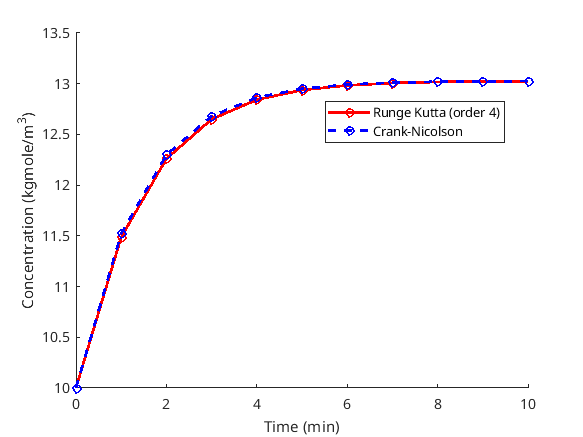

In [7]:
figure; hold on;
plot(ts_rk4, Cs_rk4, "ro-", "LineWidth", 2);
plot(ts_cn, Cs_cn, "bo--", "LineWidth", 2);
xlabel("Time (min)");
ylabel("Concentration (kgmole/m^3)");
legend("Runge Kutta (order 4)", "Crank-Nicolson", Location="best");
hold off;


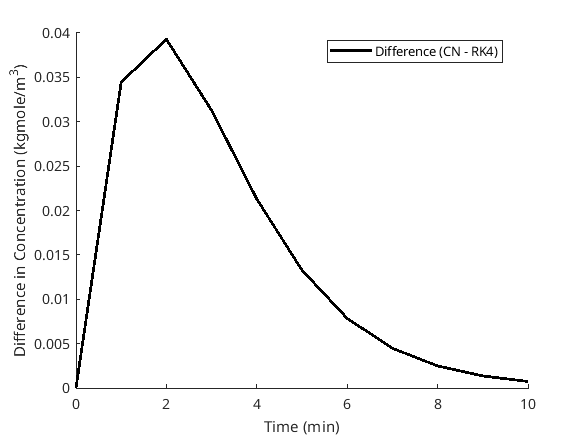

In [8]:
figure; hold on;
plot(ts_rk4, Cs_cn - Cs_rk4, "k-", "LineWidth", 2);
xlabel("Time (min)");
ylabel("Difference in Concentration (kgmole/m^3)");
legend("Difference (CN - RK4)", Location="best");
hold off;

## Discussion

- Both the solvers tend to differ more initially when the concentration is changing rapidly, but come to the same solution as $t \to \infty$ ($C_\infty \to 13.025$), which is expected as the system gets to a new steady state.
- Since this system is not stiff (step size $\gg$ time range), Runge Kutta (4th order)'s convergence is stable, but if we had a stiff system, Crank-Nicolson would have been the better choice, although more computationally expensive.

## Appendix A: Newton-Raphson Solver

In [9]:
%%file newtonraphson.m
function [final_guess, converged, guess_history] = ...
    newtonraphson(f, df, x0, epsilon, k_max) %#ok<FNDEF>

% @parameter f: function handle, f(v) = 0 defines the root to be found
% @parameter df: function handle, analytical derivative of f
% @parameter x0: initial guess (scalar)
% @parameter epsilon: tolerance factor for convergence
% @parameter k_max: maximum number of iterations

% @return final_guess: final guess vector after convergence
% @return converged: shows if convergence was achieved
% @return guess_history: history of guesses

if nargin < 5; k_max = 100; end
if nargin < 4; epsilon = 1e-6; end

k = 1; current_guess = x0; new_guess = inf;
guess_history = zeros(k_max, 1);
guess_history(1) = x0;

convergence_criteria_met = @(current_guess, new_guess) ...
    abs(new_guess - current_guess) < epsilon;
stopping_criteria_met = @(iter, current_guess, new_guess) ...
    iter >= k_max || convergence_criteria_met(current_guess, new_guess);

while ~stopping_criteria_met(k, current_guess, new_guess)
    if k > 1; current_guess = new_guess; end
    new_guess = current_guess - f(current_guess) / df(current_guess);
    k = k + 1;
    guess_history(k) = new_guess;
end % end iterating with guess in kth place

final_guess = new_guess;
converged = convergence_criteria_met(current_guess, new_guess);
guess_history = guess_history(1:k);

end

File newtonraphson.m created successfully.